In [ ]:
import torch

In [ ]:
x = torch.empty(1)

In [ ]:
print(x)

tensor([3.7936e-19])


In [ ]:
x=torch.rand(2,2)

In [ ]:
print(x)

tensor([[0.3973, 0.7575],
        [0.6407, 0.5810]])


In [ ]:
x = torch.rand(3,3)
y= torch.rand(3,3)
print(x)
print(y)

tensor([[0.9768, 0.5251, 0.1577],
        [0.5655, 0.8716, 0.3420],
        [0.2436, 0.2688, 0.4791]])
tensor([[0.6795, 0.0365, 0.2179],
        [0.8545, 0.4910, 0.6823],
        [0.4148, 0.2378, 0.5019]])


In [ ]:
y.add_(x)

tensor([[1.6563, 0.5616, 0.3756],
        [1.4200, 1.3626, 1.0244],
        [0.6584, 0.5066, 0.9810]])

In [ ]:
x = torch.rand(4,4)
print(x)

tensor([[0.9229, 0.4955, 0.1693, 0.7681],
        [0.3695, 0.5410, 0.8359, 0.0073],
        [0.1995, 0.6828, 0.6286, 0.5359],
        [0.1812, 0.0996, 0.9225, 0.4475]])


In [ ]:
print(x[:])

tensor([[0.9229, 0.4955, 0.1693, 0.7681],
        [0.3695, 0.5410, 0.8359, 0.0073],
        [0.1995, 0.6828, 0.6286, 0.5359],
        [0.1812, 0.0996, 0.9225, 0.4475]])


In [ ]:
x.view(16).shape

torch.Size([16])

In [ ]:
x.view(-1,2)

tensor([[0.9229, 0.4955],
        [0.1693, 0.7681],
        [0.3695, 0.5410],
        [0.8359, 0.0073],
        [0.1995, 0.6828],
        [0.6286, 0.5359],
        [0.1812, 0.0996],
        [0.9225, 0.4475]])

In [ ]:
#simple backpropagation

import torch

x = torch.tensor(1.0)
y = torch.tensor(2.0)

w = torch.tensor(1.0, requires_grad = True)

y_output = w*x
loss = (y_output - y)**2
loss

#backward pass

loss.backward()

print(w.grad)

learning_rate = 0.01

with torch.no_grad():
  w -=learning_rate*w.grad
w.grad.zero_()

tensor(-2.)


tensor(0.)

In [ ]:
#Linear regression

import numpy as np

X = np.array([1,2,3,4], dtype = np.float32)
Y = np.array([2,4,6,8], dtype = np.float32)

w = 0.0 #weights

#forward pass
def forward(x):
  return w*x


#loss -->MSE
def loss(y_predicted,Y):
  return ((y_predicted-Y)**2).mean()

def gradient(X,Y,y_pred):
  return (2*(y_pred-Y)*X).mean()

print(f"Prediction before training: f(5)={forward(5):.3f}")

learning_rate = 0.1

n_iter = 10

for epoch in range(n_iter):
   #prediction
   y_pred = forward(X)

   l=loss(y_pred,Y)

   #gradients
   dw = gradient(X,Y,y_pred)
   #weight updation

   w-=learning_rate*dw

   if(epoch%1==0):
    print(f'epoch {epoch+1}: w = {w:.3f}, loss = {l:.8f}')


print(f'Prediction after training : f(5) = {forward(5):.3f}')

Prediction before training: f(5)=0.000
epoch 1: w = 3.000, loss = 30.00000000
epoch 2: w = 1.500, loss = 7.50000000
epoch 3: w = 2.250, loss = 1.87500000
epoch 4: w = 1.875, loss = 0.46875000
epoch 5: w = 2.062, loss = 0.11718750
epoch 6: w = 1.969, loss = 0.02929688
epoch 7: w = 2.016, loss = 0.00732422
epoch 8: w = 1.992, loss = 0.00183105
epoch 9: w = 2.004, loss = 0.00045776
epoch 10: w = 1.998, loss = 0.00011444
Prediction after training : f(5) = 9.990


In [ ]:
#Linear regression using pytorch

import numpy as np
import torch

X = torch.tensor([1,2,3,4], dtype = torch.float32)
Y = torch.tensor([2,4,6,8], dtype = torch.float32)

w = torch.tensor(0.0,requires_grad=True) #weights

#forward pass
def forward(x):
  return w*x


#loss -->MSE
def loss(y_predicted,Y):
  return ((y_predicted-Y)**2).mean()

# def gradient(X,Y,y_pred):
#   return (2*(y_pred-Y)*X).mean()

print(f"Prediction before training: f(5)={forward(5):.3f}")

learning_rate = 0.1

n_iter = 10

for epoch in range(n_iter):
   #prediction
   y_pred = forward(X)

   l=loss(y_pred,Y)

   #gradients
   #dw = gradient(X,Y,y_pred)
   #weight updation
   l.backward()
   with torch.no_grad():
      w-=learning_rate*w.grad


   w.grad.zero_()


   if(epoch%1==0):
        print(f'epoch {epoch+1}: w = {w:.3f}, loss = {l:.8f}')


print(f'Prediction after training : f(5) = {forward(5):.3f}')

Prediction before training: f(5)=0.000
epoch 1: w = 3.000, loss = 30.00000000
epoch 2: w = 1.500, loss = 7.50000000
epoch 3: w = 2.250, loss = 1.87500000
epoch 4: w = 1.875, loss = 0.46875000
epoch 5: w = 2.062, loss = 0.11718750
epoch 6: w = 1.969, loss = 0.02929688
epoch 7: w = 2.016, loss = 0.00732422
epoch 8: w = 1.992, loss = 0.00183105
epoch 9: w = 2.004, loss = 0.00045776
epoch 10: w = 1.998, loss = 0.00011444
Prediction after training : f(5) = 9.990


In [ ]:
#Linear regression using pytorch

import numpy as np
import torch
import torch.nn as nn

X = torch.tensor([[1],[2],[3],[4]], dtype = torch.float32)
Y = torch.tensor([[2],[4],[6],[8]], dtype = torch.float32)

X_test = torch.tensor([[5]],dtype=torch.float32)
n_samples,n_features = X.shape

input_shape,output_shape = n_features,n_features
#forward pass
model = nn.Linear(input_shape,output_shape)

#loss -->MSE
loss = nn.MSELoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)

print(f"Prediction before training: f(5)={model(X_test).item():.3f}")



n_iter = 100

for epoch in range(n_iter):
   #prediction
   y_pred = model(X)

   l=loss(Y,y_pred)
   l.backward()
   optimizer.step()
   optimizer.zero_grad()


   if(epoch%1==0):
        [w,b] = model.parameters()
        print(f'epoch {epoch+1}: w = {w[0][0]:.3f}, loss = {l:.8f}')


print(f'Prediction after training : f(5) = {model(X_test).item():.3f}')

Prediction before training: f(5)=-1.513
epoch 1: w = 0.162, loss = 42.34901428
epoch 2: w = 0.459, loss = 29.38676071
epoch 3: w = 0.706, loss = 20.39251518
epoch 4: w = 0.912, loss = 14.15159225
epoch 5: w = 1.084, loss = 9.82113457
epoch 6: w = 1.227, loss = 6.81631231
epoch 7: w = 1.346, loss = 4.73132038
epoch 8: w = 1.445, loss = 3.28457975
epoch 9: w = 1.528, loss = 2.28070545
epoch 10: w = 1.597, loss = 1.58413064
epoch 11: w = 1.654, loss = 1.10078096
epoch 12: w = 1.702, loss = 0.76538640
epoch 13: w = 1.742, loss = 0.53265345
epoch 14: w = 1.775, loss = 0.37115514
epoch 15: w = 1.803, loss = 0.25908595
epoch 16: w = 1.826, loss = 0.18131438
epoch 17: w = 1.845, loss = 0.12734096
epoch 18: w = 1.862, loss = 0.08988081
epoch 19: w = 1.875, loss = 0.06387890
epoch 20: w = 1.886, loss = 0.04582767
epoch 21: w = 1.896, loss = 0.03329329
epoch 22: w = 1.904, loss = 0.02458702
epoch 23: w = 1.910, loss = 0.01853718
epoch 24: w = 1.916, loss = 0.01433040
epoch 25: w = 1.920, loss = 0

In [ ]:
#Linear regression using pytorch

import numpy as np
import torch
import torch.nn as nn

X = torch.tensor([[1],[2],[3],[4]], dtype = torch.float32)
Y = torch.tensor([[2],[4],[6],[8]], dtype = torch.float32)

X_test = torch.tensor([[5]],dtype=torch.float32)
n_samples,n_features = X.shape

input_shape,output_shape = n_features,n_features
#forward pass
model = nn.Linear(input_shape,output_shape)

class LinearRegression(nn.Module):

  def __init__(self,intput_shape,output_shape):
    super(LinearRegression,self).__init__()
    self.lin = nn.Linear(input_shape,output_shape)

  def forward(self,x):
    return self.lin(x)


model = LinearRegression(input_shape,output_shape)
loss = nn.MSELoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)

print(f"Prediction before training: f(5)={model(X_test).item():.3f}")



n_iter = 100

for epoch in range(n_iter):
   #prediction
   y_pred = model(X)

   l=loss(Y,y_pred)
   l.backward()
   optimizer.step()
   optimizer.zero_grad()


   if(epoch%1==0):
        [w,b] = model.parameters()
        print(f'epoch {epoch+1}: w = {w[0][0]:.3f}, loss = {l:.8f}')


print(f'Prediction after training : f(5) = {model(X_test).item():.3f}')

Prediction before training: f(5)=-0.394
epoch 1: w = 0.193, loss = 31.67582703
epoch 2: w = 0.450, loss = 22.01171494
epoch 3: w = 0.664, loss = 15.30580425
epoch 4: w = 0.843, loss = 10.65252113
epoch 5: w = 0.992, loss = 7.42351341
epoch 6: w = 1.116, loss = 5.18278122
epoch 7: w = 1.219, loss = 3.62779474
epoch 8: w = 1.306, loss = 2.54863524
epoch 9: w = 1.378, loss = 1.79964089
epoch 10: w = 1.438, loss = 1.27974284
epoch 11: w = 1.488, loss = 0.91881150
epoch 12: w = 1.530, loss = 0.66818446
epoch 13: w = 1.565, loss = 0.49409646
epoch 14: w = 1.595, loss = 0.37311834
epoch 15: w = 1.619, loss = 0.28899294
epoch 16: w = 1.640, loss = 0.23044036
epoch 17: w = 1.657, loss = 0.18963289
epoch 18: w = 1.672, loss = 0.16113982
epoch 19: w = 1.684, loss = 0.14119250
epoch 20: w = 1.694, loss = 0.12717567
epoch 21: w = 1.703, loss = 0.11727529
epoch 22: w = 1.710, loss = 0.11023184
epoch 23: w = 1.717, loss = 0.10517213
epoch 24: w = 1.722, loss = 0.10148974
epoch 25: w = 1.727, loss = 0

epoch: 10, loss = 2886.311
epoch: 20, loss = 2427.940
epoch: 30, loss = 2099.012
epoch: 40, loss = 1862.597
epoch: 50, loss = 1692.425
epoch: 60, loss = 1569.767
epoch: 70, loss = 1481.246
epoch: 80, loss = 1417.288
epoch: 90, loss = 1371.029
epoch: 100, loss = 1337.539


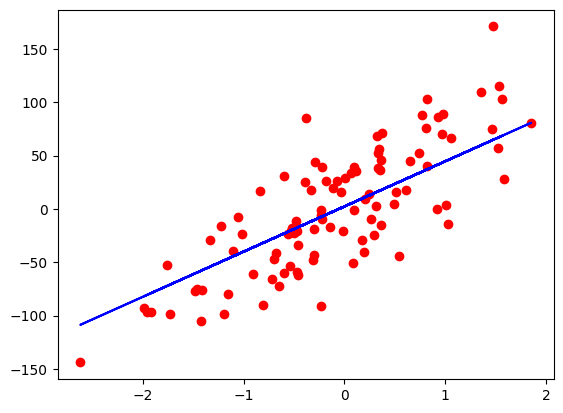

In [ ]:
#LINEAR REGRESSION

import numpy as np
from sklearn import datasets
import torch
import matplotlib.pyplot as plt
import torch.nn as nn


X_numpy,y_numpy = datasets.make_regression(n_samples=100,n_features=1,random_state=42,noise=40)

X = torch.from_numpy(X_numpy.astype(np.float32))
y = torch.from_numpy(y_numpy.astype(np.float32))

y=y.view(y.shape[0],1)

n_samples,n_features = X.shape

input_size = n_features
output_size = 1

model = nn.Linear(input_size,output_size)

learning_rate = 0.01
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)

num_epoch= 100
for epoch in range(num_epoch):

  y_pred=model(X)

  loss=criterion(y,y_pred)

  loss.backward()

  optimizer.step()

  optimizer.zero_grad()
  if(epoch+1)%10==0:
    print(f'epoch: {epoch+1}, loss = {loss.item():.3f}')

predicted = model(X).detach()
plt.plot(X_numpy,y_numpy,'ro')
plt.plot(X_numpy,predicted,'b')
plt.show()